### CO₂ hourly averages for 4st of each month (Apr–Oct 2025),
3 rooms, 7 charts


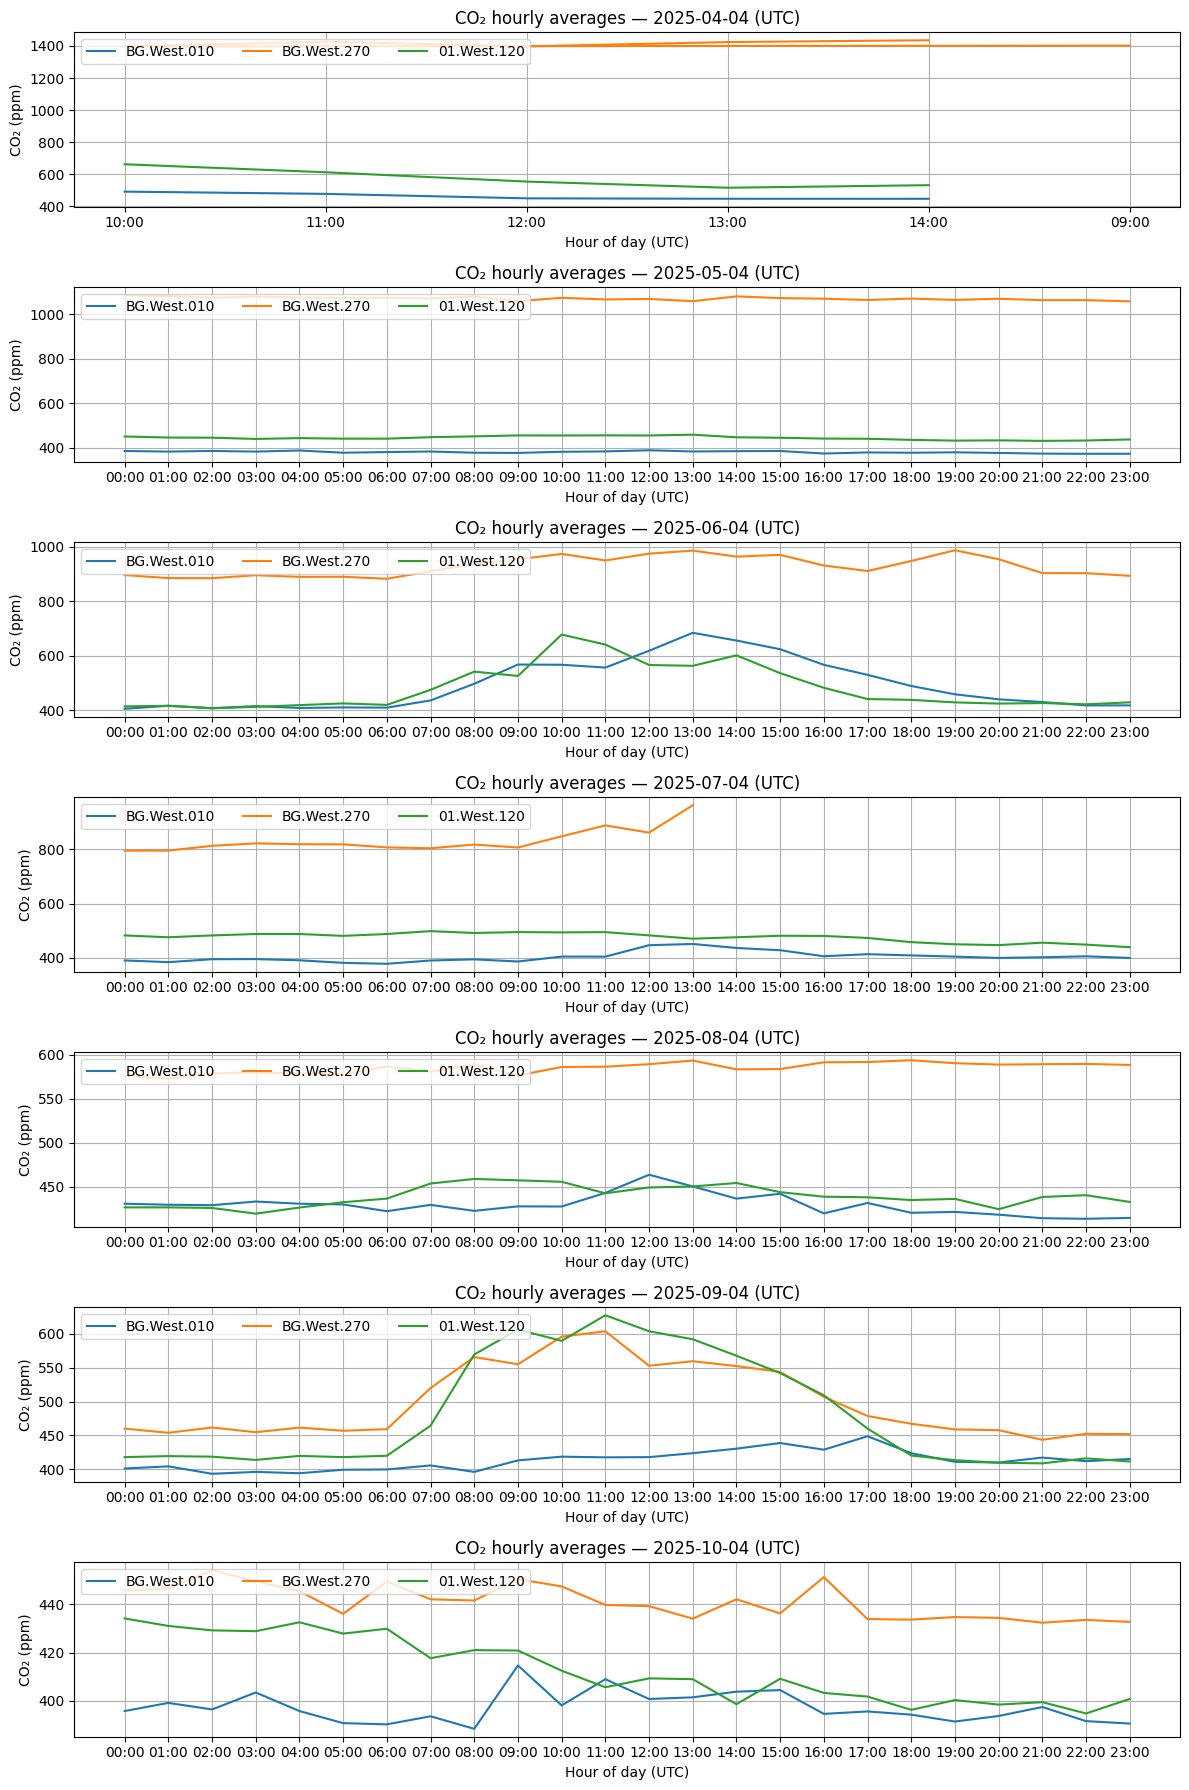

In [4]:

# Cell 1: Imports & config
import requests
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import urljoin, urlencode
from datetime import datetime, timedelta, timezone

# >>>>>> FILL THESE with your CO₂ Observations endpoints (from your previous notebook) <<<<<<
ROOMS = [
    {
        "name": "BG.West.010",
        "observations_url": "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(3)/Observations"
    },
    {
        "name": "BG.West.270",
        "observations_url": "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(9)/Observations"
    },
    {
        "name": "01.West.120",
        "observations_url": "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(15)/Observations"
    },
]

# Plot look & feel
plt.rcParams["figure.figsize"] = (12, 18)  # wide & tall for 7 subplots
plt.rcParams["axes.grid"] = True

# Helper: robust GET with small timeout
def _get_json(url, params=None, timeout=20):
    r = requests.get(url, params=params, timeout=timeout)
    r.raise_for_status()
    return r.json()

# Helper: pull all observations in a time window, following @iot.nextLink pagination
def fetch_observations_window(observations_url: str, start_utc: datetime, end_utc: datetime):
    """
    Fetch all Observations between [start_utc, end_utc) for a single Observations endpoint.
    Returns a list of dicts with at least: phenomenonTime, result.
    """
    assert start_utc.tzinfo is not None and end_utc.tzinfo is not None, "Use timezone-aware datetimes (UTC)."

    # OGC SensorThings API filter
    # Example filter:
    #   phenomenonTime ge 2025-04-01T00:00:00Z and phenomenonTime lt 2025-04-02T00:00:00Z
    f_start = start_utc.isoformat().replace("+00:00", "Z")
    f_end = end_utc.isoformat().replace("+00:00", "Z")
    filt = f"phenomenonTime ge {f_start} and phenomenonTime lt {f_end}"

    params = {
        "$filter": filt,
        "$orderby": "phenomenonTime asc",
        "$top": 1000  # pull in big chunks
    }

    out = []
    data = _get_json(observations_url, params=params)

    while True:
        val = data.get("value", [])
        out.extend(val)
        next_link = data.get("@iot.nextLink")
        if not next_link:
            break
        data = _get_json(next_link)

    return out

# Helper: convert raw observations to hourly-mean series
def hourly_mean_from_observations(observations):
    if not observations:
        return pd.DataFrame(columns=["hour", "co2"])

    # Extract times & values (assumes numeric ppm in 'result')
    df = pd.DataFrame(
        [
            {
                "phenomenon_time": o.get("phenomenonTime"),
                "co2": o.get("result")
            }
            for o in observations
            if "phenomenonTime" in o and "result" in o
        ]
    )

    if df.empty:
        return pd.DataFrame(columns=["hour", "co2"])

    # Parse timestamps (typically ISO8601 with Z)
    df["phenomenon_time"] = pd.to_datetime(df["phenomenon_time"], utc=True, errors="coerce")
    df = df.dropna(subset=["phenomenon_time"])

    # Create an "hour" bin (start of each hour)
    df["hour"] = df["phenomenon_time"].dt.floor("h")

    # Hourly mean
    hourly = df.groupby("hour", as_index=False)["co2"].mean()
    return hourly

# Cell 2: Build the 7 dates (2nd of each month Apr–Oct 2025, UTC)
month_starts = pd.date_range("2025-04-01", "2025-10-01", freq="MS", tz="UTC")
# dates_utc = list(month_starts)  # 7 dates
dates_utc = [d + pd.Timedelta(days=3) for d in month_starts]  # shift each to the 2nd

# Cell 3: Fetch, aggregate, and plot
fig, axes = plt.subplots(nrows=7, ncols=1, sharex=False)
if 7 == 1:
    axes = [axes]  # safety if someone changes the range

for ax, day in zip(axes, dates_utc):
    day_start = day
    day_end = day + timedelta(days=1)

    # Collect per-room hourly series
    series_per_room = {}
    for room in ROOMS:
        obs = fetch_observations_window(room["observations_url"], day_start, day_end)
        hourly = hourly_mean_from_observations(obs)
        series_per_room[room["name"]] = hourly

    # Plot: three lines for the three rooms
    for room_name, hourly in series_per_room.items():
        if hourly.empty:
            # show an empty line to keep legend stable
            ax.plot([], [], label=f"{room_name} (no data)")
        else:
            ax.plot(hourly["hour"].dt.tz_convert("UTC").dt.strftime("%H:%M"), hourly["co2"], label=room_name)

    # Axis/labels
    title_day = day_start.astimezone(timezone.utc).strftime("%Y-%m-%d (UTC)")
    ax.set_title(f"CO₂ hourly averages — {title_day}")
    ax.set_ylabel("CO₂ (ppm)")
    ax.set_xlabel("Hour of day (UTC)")
    ax.legend(loc="upper left", ncol=3)
    ax.grid(True)

plt.tight_layout()
plt.show()

# --- Optional: save the figure ---
# fig.savefig("co2_3rooms_7days_apr_to_oct_2025.png", dpi=150, bbox_inches="tight")

### Now, weekly patterns - one average value per day
following codeblock builds target dates (the 2nd of each month), snaps to the previous Sunday, defines a Sun→Sat week.
* If that entire week is empty across all three rooms, it auto-shifts forward up to 5 days to find the first week with any CO₂ data.
* For each week, it computes one average per day per room and plots seven panels (Apr→Oct).


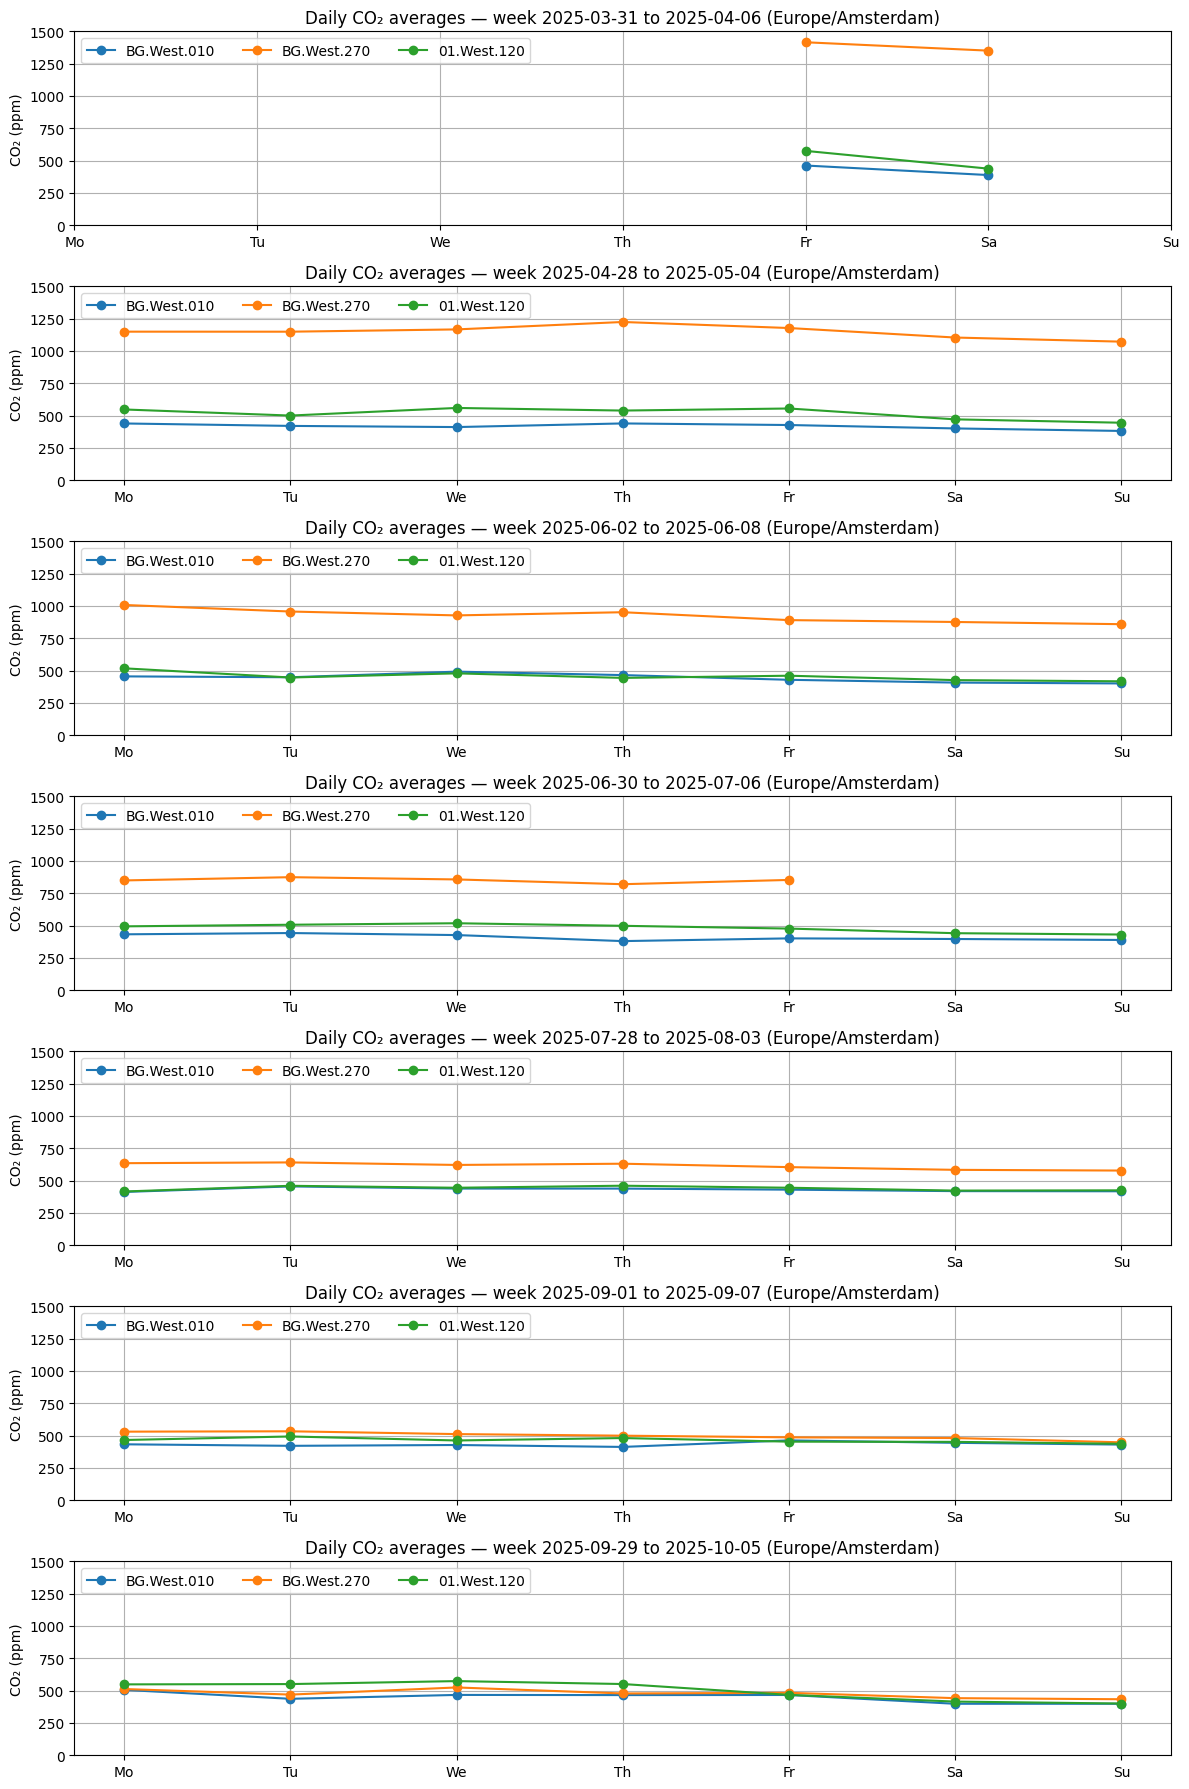

In [ ]:
# === Weekly CO₂ trends (LOCAL time): one Monday–Sunday week per month (Apr–Oct 2025) ===
# Uses Europe/Amsterdam for week alignment and daily grouping; queries FROST in UTC.
ROOMS = [
    {"name": "BG.West.010", "observations_url": "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(3)/Observations"},
    {"name": "BG.West.270", "observations_url": "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(9)/Observations"},
    {"name": "01.West.120", "observations_url": "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(15)/Observations"},
]

import requests
import pandas as pd
import matplotlib.pyplot as plt

LOCAL_TZ = "Europe/Amsterdam"           # <<< your study area time zone
TARGET_DAY_OF_MONTH = 2                 # aim for the 2nd of each month (LOCAL)
AUTO_SHIFT_LOOKAHEAD_DAYS = 5           # if the whole week is empty, look ahead up to N days

plt.rcParams["figure.figsize"] = (12, 18)
plt.rcParams["axes.grid"] = True


# ----------------------- Helpers -----------------------
def _get_json(url, params=None, timeout=20):
    r = requests.get(url, params=params, timeout=timeout)
    r.raise_for_status()
    return r.json()

def fetch_observations_window(observations_url: str, start_utc: pd.Timestamp, end_utc: pd.Timestamp):
    """
    Fetch Observations between [start_utc, end_utc) in UTC. Follows @iot.nextLink.
    """
    assert start_utc.tzinfo is not None and end_utc.tzinfo is not None, "UTC timestamps required."
    f_start = start_utc.isoformat().replace("+00:00", "Z")
    f_end   = end_utc.isoformat().replace("+00:00", "Z")
    params = {"$filter": f"phenomenonTime ge {f_start} and phenomenonTime lt {f_end}",
              "$orderby": "phenomenonTime asc", "$top": 1000}
    out = []
    data = _get_json(observations_url, params=params)
    while True:
        out.extend(data.get("value", []))
        nxt = data.get("@iot.nextLink")
        if not nxt:
            break
        data = _get_json(nxt)
    return out

def daily_mean_local(observations, local_tz: str):
    """
    Group by LOCAL calendar day. Returns DF with columns ['date', 'co2'] where 'date' is LOCAL midnight.
    """
    if not observations:
        return pd.DataFrame(columns=["date", "co2"])
    df = pd.DataFrame(
        [{"phenomenon_time": o.get("phenomenonTime"), "co2": o.get("result")}
         for o in observations if "phenomenonTime" in o and "result" in o]
    )
    if df.empty:
        return pd.DataFrame(columns=["date", "co2"])

    # Parse as UTC, convert to LOCAL, then floor to LOCAL day
    df["phenomenon_time"] = pd.to_datetime(df["phenomenon_time"], utc=True, errors="coerce")
    df = df.dropna(subset=["phenomenon_time"])
    df["local_time"] = df["phenomenon_time"].dt.tz_convert(local_tz)
    df["date"] = df["local_time"].dt.floor("D")   # LOCAL midnight bins
    return df.groupby("date", as_index=False)["co2"].mean()

def has_any_data(urls, start_utc, end_utc) -> bool:
    """
    Fast existence check across URLs in a UTC window.
    """
    f_start = start_utc.isoformat().replace("+00:00","Z")
    f_end   = end_utc.isoformat().replace("+00:00","Z")
    for u in urls:
        data = _get_json(u, {"$filter": f"phenomenonTime ge {f_start} and phenomenonTime lt {f_end}", "$top": 1})
        if data.get("value"):
            return True
    return False

def week_start_monday_local(d_local: pd.Timestamp) -> pd.Timestamp:
    """
    Given a LOCAL timestamp, return the Monday 00:00 LOCAL at/before it.
    """
    return (d_local - pd.Timedelta(days=d_local.weekday())).floor("D")


# ----------------------- Build one LOCAL week per month -----------------------
# Build month starts in LOCAL tz so “2nd of month” is truly local (handles DST properly).
month_starts_local = pd.date_range("2025-04-01", "2025-10-01", freq="MS", tz=LOCAL_TZ)
target_days_local  = [m + pd.Timedelta(days=TARGET_DAY_OF_MONTH - 1) for m in month_starts_local]

co2_urls = [r["observations_url"] for r in ROOMS]
weeks_local = []  # list of (ws_local, we_local)

for td_local in target_days_local:
    ws_local = week_start_monday_local(td_local)        # Monday 00:00 LOCAL
    we_local = ws_local + pd.Timedelta(days=7)

    # If that whole LOCAL week is empty, try shifting forward up to N days.
    picked = None
    for i in range(AUTO_SHIFT_LOOKAHEAD_DAYS + 1):
        s_loc = ws_local + pd.Timedelta(days=i)
        e_loc = s_loc + pd.Timedelta(days=7)
        # Convert LOCAL week to UTC for API query window
        s_utc = s_loc.tz_convert("UTC")
        e_utc = e_loc.tz_convert("UTC")
        if has_any_data(co2_urls, s_utc, e_utc):
            picked = (s_loc, e_loc)
            break

    weeks_local.append(picked if picked else (ws_local, we_local))


# ----------------------- Fetch, aggregate (LOCAL), and plot -----------------------
labels = ["Mo","Tu","We","Th","Fr","Sa","Su"]
fig, axes = plt.subplots(nrows=len(weeks_local), ncols=1, sharex=False)
if len(weeks_local) == 1:
    axes = [axes]

for ax, (ws_loc, we_loc) in zip(axes, weeks_local):
    # LOCAL day bins for plotting/reindexing
    days_local = [ws_loc + pd.Timedelta(days=i) for i in range(7)]

    # UTC range for fetching from FROST
    ws_utc = ws_loc.tz_convert("UTC")
    we_utc = we_loc.tz_convert("UTC")

    # Collect per-room daily means (LOCAL)
    series = {}
    for room in ROOMS:
        obs = fetch_observations_window(room["observations_url"], ws_utc, we_utc)
        daily = daily_mean_local(obs, LOCAL_TZ).set_index("date").reindex(days_local)
        series[room["name"]] = daily["co2"].values

    # Plot lines
    x = range(7)
    for room in ROOMS:
        ax.plot(x, series[room["name"]], marker="o", label=room["name"])
    ax.set_ylim(0, 1500)

    # Labels and title (LOCAL dates)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel("CO₂ (ppm)")
    title_start = ws_loc.strftime('%Y-%m-%d')
    title_end   = (we_loc - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
    ax.set_title(f"Daily CO₂ averages — week {title_start} to {title_end} ({LOCAL_TZ})")
    ax.legend(loc="upper left", ncol=3); ax.grid(True)

plt.tight_layout(); plt.show()


### Extracting Room Area from IFC 
#### (tries GrossFloorArea, falling back to NetFloorArea/Area)

Codeblock below reads an IFC once, finds each requested space by Name or LongName, and pulls volume and area from the standard BaseQuantities property set. It mirrors how ifc_parsers.py grabs volume (from GrossVolume) and applies the same approach to area (tries GrossFloorArea, falling back to NetFloorArea/Area if needed).

In [4]:
# --- Room volume & area from IFC (no custom classes needed) ---

# 1) configure your IFC path and room list
IFC_PATH = "..\static\IFC\BK_v6_ifc4_georef_transformed.ifc"   # <-- update this
ROOMS = [
    {"name": "BG.West.010"},
    {"name": "BG.West.270"},
    {"name": "01.West.120"},
]

# 2) imports
import ifcopenshell
import pandas as pd
from ifcopenshell.util.element import get_psets

# 3) helpers
def _first(*vals):
    """Return the first non-None/non-zero-like value."""
    for v in vals:
        if v not in (None, "", 0):
            return v
    return None

def _find_space(model, target_name: str):
    t = target_name.strip().lower()
    for sp in model.by_type("IfcSpace"):
        longn  = (sp.LongName or "").strip().lower()
        shortn = (sp.Name or "").strip().lower()
        if t == longn or t == shortn:
            return sp
    return None

def room_volume_area(model, room_name: str):
    sp = _find_space(model, room_name)
    if sp is None:
        return {"name": room_name, "volume_m3": None, "area_m2": None, "found": False}

    psets = get_psets(sp)
    bq = psets.get("BaseQuantities", {})  # standard place for quantities

    # Match your parser's logic for volume (GrossVolume first). :contentReference[oaicite:1]{index=1}
    volume = _first(bq.get("GrossVolume"), bq.get("NetVolume"), bq.get("Volume"))

    # Apply the same pattern for area.
    area = _first(bq.get("GrossFloorArea"), bq.get("NetFloorArea"), bq.get("Area"))

    # Normalize to floats if present
    volume = float(volume) if volume is not None else None
    area   = float(area) if area   is not None else None

    return {"name": room_name, "volume_m3": volume, "area_m2": area, "found": True}

# 4) run
model = ifcopenshell.open(IFC_PATH)
rows = [room_volume_area(model, r["name"]) for r in ROOMS]
df = pd.DataFrame(rows)
df


,name,volume_m3,area_m2,found
0,BG.West.010,439.675687,79.220844,True
1,BG.West.270,202.370533,36.463159,True
2,01.West.120,122.652271,40.213859,True
